# 02 - Phase de recherche (dataset Kaggle simple)

Ce notebook retrace la phase exploratoire du projet : mise en place du pipeline, glossaire des métriques, comparaison des versions de prompt (`baseline v0` à `improved v5`), analyse des erreurs et de la latence. Tout est fait sur le dataset Kaggle "pilote" (`fkarimovv/abnormal-lung`).

Pour la comparaison finale baseline vs meilleur prompt sur le dataset RSNA (officiel), voir `06_prompt_comparison.ipynb`. Pour la visualisation brute des tables et la qualité d'image RSNA, voir `05_Database_visualisation_evaluation_rsna.ipynb`.

## Métriques visées

Pour rappel nous travaillons sur trois classes : `suspected_opacity`, `normal`, `uncertain`

Ce notebook calcule toujours les  métriques définies dans `docs/evaluation_protocol.md`. 
Petit glossaire pour ne pas s'y perdre :

- **Accuracy** : proportion de prédictions correctes, toutes classes confondues (peut cacher un déséquilibre si une classe est plus fréquente que l'autre)
- **Macro-F1** : moyenne du F1-score (précision + rappel combinés) calculé séparément pour chaque classe puis clacul de la moeynne -> permet de vérifier que le modèle est bon sur *chaque* classe, pas seulement en moyenne globale. On ne moyenne que sur les classes réellement présentes dans les vrais labels (`normal`, `suspected_opacity`)
- **Sensibilité** (rappel sur `suspected_opacity`) : parmi les vraies anomalies, combien sont détectées -> **C'est la métrique la plus importante ici** : rater une anomalie (un faux négatif) est plus grave que déclencher une fausse alerte, dans un contexte médical.
- **Spécificité** (rappel sur `normal`) : parmi les vrais cas normaux, combien sont bien reconnus comme normaux -> évite de noyer l'utilisateur sous de fausses alertes
- **Taux d'incertitude** : proportion de réponses `uncertain` -> Trop bas = le modèle est peut-être trop confiant à tort / Trop haut = l'outil devient inutile (il ne tranche jamais)
- **Taux de JSON valide / taux de warning** : vérifient que la sortie reste exploitable et que l'avertissement obligatoire est toujours présent (exigence éthique du cahier des charges)
- **Latence (médiane)** : temps d'inférence en secondes. On regarde la médiane plutôt que la moyenne car quelques cas très lents (GPU qui chauffe) ne doivent pas fausser l'estimation du temps de réponse typique

Le but du notebook : comparer la baseline (`baseline_prompt_0`) aux versions améliorées du prompt (`improved_prompt_1` à `improved_prompt_5`) sur ces métriques, pour améliorer le prompt au fur et à mesure.

## 1. Set up
### Import des librairies (pandas pour les tableaux, seaborn/matplotlib pour les graphiques) et des modules du projet (`src/`)

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from src.inference import vlm_predict_placeholder
from src.guardrails import apply_safety_guardrails

c:\Users\auber.MSI\Projets\TD-Mastercamp\SolutionDelivery\Assistant-Radiologique-Virtuel-Intelligent-pour-Radiographies-X\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Check le nombre d'images disponibles et le temps pour tester le modèle

In [2]:
data_root = Path('../data')
folder = 'brutes_kaggle'
total = len(list((data_root / folder).glob('*.jpg')))
print(f"Total images : {total}")
print(f"Temps estimé VLM : ~{total * 40 // 60} minutes")

Total images : 932
Temps estimé VLM : ~621 minutes


## 2. Mini batch
### Résultat du mini batch extraits de `results/batch_results.csv`
Run avec le fichier : `scripts/run_batch.py` (15 cas pour éviter les problèmes de gpu)

Justification : vu le temps estimé ci-dessus (~40s par cas), lancer MedGemma sur les 932 images pour un simple test prendrait des heures. Ce mini batch sert de vérification rapide (le pipeline fonctionne, le JSON est valide) avant de lancer la vraie évaluation sur la base de données (section 3).

In [4]:
# print batch_results.csv saved under results directory as csvfile
df_final = pd.read_csv('../results/batch_results.csv')
display(df_final)

,case_id,file,path,folder,ground_truth,toy_class,toy_confidence,vlm_baseline_class,vlm_baseline_confidence,vlm_improved_class,vlm_improved_confidence
0,1,NORMAL-LUNG_00115_normal_142.jpg,data\normal_lung_probe\NORMAL-LUNG_00115_norma...,normal_lung_probe,normal,normal,0.743,normal,0.95,normal,0.8
1,2,NORMAL-LUNG_00026_normal_036.jpg,data\normal_lung_probe\NORMAL-LUNG_00026_norma...,normal_lung_probe,normal,normal,0.730,normal,0.95,normal,0.8
2,3,NORMAL-LUNG_00282_normal_320.jpg,data\normal_lung_probe\NORMAL-LUNG_00282_norma...,normal_lung_probe,normal,normal,0.752,normal,0.95,normal,0.8
3,4,NORMAL-LUNG_00251_normal_285.jpg,data\normal_lung_probe\NORMAL-LUNG_00251_norma...,normal_lung_probe,normal,normal,0.728,normal,0.95,normal,0.8
4,5,NORMAL-LUNG_00229_normal_262.jpg,data\normal_lung_probe\NORMAL-LUNG_00229_norma...,normal_lung_probe,normal,normal,0.739,normal,0.95,normal,0.8
5,6,ABNORMAL-LUNG_00143_suspected_opacity_152.jpg,data\lung_images\ABNORMAL-LUNG_00143_suspected...,lung_images,suspected_opacity,suspected_opacity,0.704,normal,0.95,normal,0.8
6,7,NORMAL-LUNG_00755_normal_374.jpg,data\lung_images\NORMAL-LUNG_00755_normal_374.jpg,lung_images,normal,normal,0.731,normal,0.80,normal,0.8
7,8,ABNORMAL-LUNG_00105_suspected_opacity_112.jpg,data\lung_images\ABNORMAL-LUNG_00105_suspected...,lung_images,suspected_opacity,suspected_opacity,0.717,suspected_opacity,0.30,normal,0.8
8,9,NORMAL-LUNG_00693_normal_308.jpg,data\lung_images\NORMAL-LUNG_00693_normal_308.jpg,lung_images,normal,normal,0.747,normal,0.95,normal,0.8
9,10,NORMAL-LUNG_00759_normal_378.jpg,data\lung_images\NORMAL-LUNG_00759_normal_378.jpg,lung_images,normal,normal,0.714,normal,0.95,normal,0.8


### Calculs des métriques pour la comparaison
(voir le glossaire des métriques tout en haut du notebook pour la définition de chacune)


=== VLM Baseline ===
Total : 15
Taux uncertain    : 6.7%
Accuracy : 60.0%
Macro F1 : 0.506
Sensibilité : 14.3%
Spécificité : 100.0%


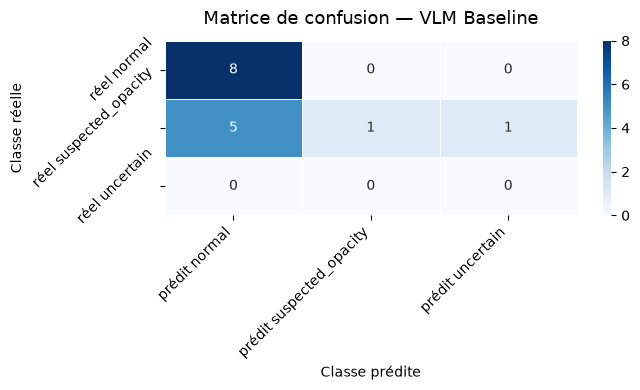


=== VLM Improved ===
Total : 15
Taux uncertain    : 0.0%
Accuracy : 53.3%
Macro F1 : 0.348
Sensibilité : 0.0%
Spécificité : 100.0%


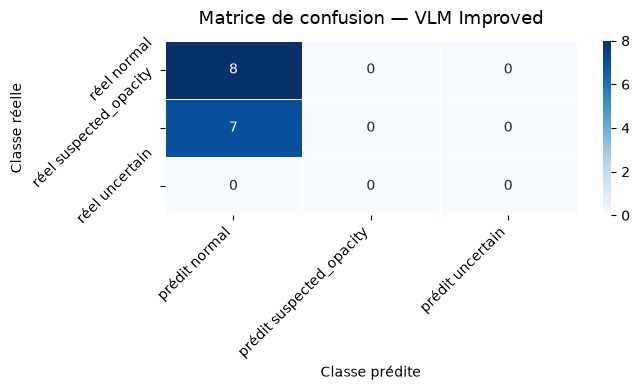

In [5]:
from src.metrics import summarize_metrics, confusion_matrix_numpy

df_final = pd.read_csv('../results/batch_results.csv')

CLASSES = ['normal', 'suspected_opacity', 'uncertain']
modes = {
    'VLM Baseline': 'vlm_baseline_class',
    'VLM Improved': 'vlm_improved_class',
}

for label, col in modes.items():
    print(f"\n=== {label} ===")
    valid = df_final[df_final[col].notna() & (df_final[col] != 'error')].copy()

    # Métriques globales (uncertain inclus)
    rows = [{"label": t, "predicted_class": p, "warning": True}
            for t, p in zip(valid['ground_truth'], valid[col])]
    m = summarize_metrics(rows)
    print(f"Total : {m['n']}")
    print(f"Taux uncertain    : {m['uncertain_rate']:.1%}")
    print(f"Accuracy : {m['accuracy']:.1%}")
    print(f"Macro F1 : {m['macro_f1']:.3f}")
    print(f"Sensibilité : {m['sensitivity']:.1%}")
    print(f"Spécificité : {m['specificity']:.1%}")

    # Matrice de confusion
    cm = confusion_matrix_numpy(valid['ground_truth'], valid[col], CLASSES)
    cm_df = pd.DataFrame(cm,
        index=[f'réel {c}' for c in CLASSES],
        columns=[f'prédit {c}' for c in CLASSES])

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
    ax.set_title(f'Matrice de confusion — {label}', fontsize=13, pad=12)
    ax.set_ylabel('Classe réelle')
    ax.set_xlabel('Classe prédite')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 3. Résultats des runs sauvegardés dans la database

Ici on quitte le mini batch et on passe aux vrais résultats : en moyenne 100 runs par prompts sur les 932 radios (dataset Kaggle `fkarimovv/abnormal-lung`), évaluées avec 6 prompts différents (`baseline v0` puis `improved v1` à `v5`), tous stockés dans `data/database_kaggle_dataset.sqlite`.

Ce notebook est dédié au dataset Kaggle. Le dataset RSNA (le vrai dataset attendu par le cahier des charges) a sa propre base `data/database.sqlite` et son propre notebook de visualisation — Kaggle a juste servi de premier jeu de données car plus simple/rapide à importer pour démarrer le pipeline.

### Affichage de la table à étudier (jointure entre `runs` et `evaluations`)

In [4]:
# Chemin vers la base Kaggle (dataset pilote, pas la base RSNA active)
DB_PATH = Path('../data/database_kaggle_dataset.sqlite')

In [5]:
from src.database import get_evaluations

rows = get_evaluations(DB_PATH)
df = pd.DataFrame(rows)

df.head()


,case_id,run_id,evaluation_id,prompt_id,prompt_name,prompt_version,ground_truth_label,predicted_class,confidence,latency
0,17,1,1,1,baseline,v0,suspected_opacity,normal,0.95,52971
1,29,83,83,1,baseline,v0,suspected_opacity,normal,0.95,35864
2,34,50,50,1,baseline,v0,suspected_opacity,normal,0.95,39044
3,37,55,55,1,baseline,v0,suspected_opacity,normal,0.80,44824
4,72,62,62,1,baseline,v0,suspected_opacity,normal,0.95,35904


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 465 entries, 0 to 464
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   case_id             465 non-null    int64  
 1   run_id              465 non-null    int64  
 2   evaluation_id       465 non-null    int64  
 3   prompt_id           465 non-null    int64  
 4   prompt_name         465 non-null    str    
 5   prompt_version      465 non-null    str    
 6   ground_truth_label  465 non-null    str    
 7   predicted_class     465 non-null    str    
 8   confidence          465 non-null    float64
 9   latency             465 non-null    int64  
dtypes: float64(1), int64(5), str(4)
memory usage: 36.5 KB


### Résultats bruts de MedGemma pour chaque prompt
Une table par prompt (baseline, puis chaque version améliorée). C'est juste pour inspecter les prédictions une par une, ensuite nous verrons les métriques agrégées

In [9]:
# Improved prompt 1
df_version = df[df['prompt_id'] == 2 ]
df_version

,case_id,run_id,evaluation_id,prompt_id,prompt_name,prompt_version,ground_truth_label,predicted_class,confidence,latency
100,17,101,101,2,improved,v1,suspected_opacity,normal,0.8,32854
101,29,183,183,2,improved,v1,suspected_opacity,normal,0.8,33556
102,34,150,150,2,improved,v1,suspected_opacity,normal,0.8,40038
103,37,155,155,2,improved,v1,suspected_opacity,normal,0.8,40375
104,72,162,162,2,improved,v1,suspected_opacity,normal,0.8,33489
...,...,...,...,...,...,...,...,...,...,...
195,849,159,159,2,improved,v1,normal,normal,0.8,37080
196,852,182,182,2,improved,v1,normal,normal,0.8,41933
197,879,130,130,2,improved,v1,normal,normal,0.8,41835
198,884,195,195,2,improved,v1,normal,normal,0.8,39508


In [10]:
# Improved prompt 2
df_version = df[df['prompt_id'] == 3 ]
df_version

,case_id,run_id,evaluation_id,prompt_id,prompt_name,prompt_version,ground_truth_label,predicted_class,confidence,latency
200,1,212,212,3,improved,v2,suspected_opacity,normal,0.8,39354
201,5,213,213,3,improved,v2,suspected_opacity,normal,0.8,36195
202,12,214,214,3,improved,v2,suspected_opacity,normal,0.8,36402
203,17,201,201,3,improved,v2,suspected_opacity,normal,0.8,52288
204,18,221,221,3,improved,v2,suspected_opacity,normal,0.8,42063
205,19,222,222,3,improved,v2,suspected_opacity,normal,0.8,40502
206,42,215,215,3,improved,v2,suspected_opacity,normal,0.8,35247
207,53,207,207,3,improved,v2,suspected_opacity,normal,0.8,42279
208,72,206,206,3,improved,v2,suspected_opacity,normal,0.8,35388
209,347,211,211,3,improved,v2,suspected_opacity,normal,0.8,42113


In [11]:
# Improved prompt 3
df_version = df[df['prompt_id'] == 4 ]
df_version

,case_id,run_id,evaluation_id,prompt_id,prompt_name,prompt_version,ground_truth_label,predicted_class,confidence,latency
224,7,253,253,4,improved,v3,suspected_opacity,normal,0.85,44349
225,14,237,237,4,improved,v3,suspected_opacity,normal,0.85,39135
226,16,231,231,4,improved,v3,suspected_opacity,normal,0.85,35388
227,18,225,225,4,improved,v3,suspected_opacity,suspected_opacity,0.75,62959
228,19,226,226,4,improved,v3,suspected_opacity,suspected_opacity,0.75,57847
229,48,240,240,4,improved,v3,suspected_opacity,suspected_opacity,0.75,34653
230,65,254,254,4,improved,v3,suspected_opacity,normal,0.85,33824
231,102,246,246,4,improved,v3,suspected_opacity,normal,0.85,35729
232,112,247,247,4,improved,v3,suspected_opacity,suspected_opacity,0.75,43512
233,120,251,251,4,improved,v3,suspected_opacity,suspected_opacity,0.75,41896


In [12]:
# Improved prompt 4
df_version = df[df['prompt_id'] == 5 ]
df_version

,case_id,run_id,evaluation_id,prompt_id,prompt_name,prompt_version,ground_truth_label,predicted_class,confidence,latency
250,10,256,256,5,improved,v4,suspected_opacity,suspected_opacity,0.80,58053
251,12,255,255,5,improved,v4,suspected_opacity,suspected_opacity,0.80,46730
252,13,380,377,5,improved,v4,suspected_opacity,suspected_opacity,0.75,12175
253,16,270,267,5,improved,v4,suspected_opacity,normal,0.85,15645
254,17,287,284,5,improved,v4,suspected_opacity,suspected_opacity,0.75,23787
...,...,...,...,...,...,...,...,...,...,...
360,849,313,310,5,improved,v4,normal,suspected_opacity,0.75,21184
361,852,375,372,5,improved,v4,normal,normal,0.85,15817
362,879,295,292,5,improved,v4,normal,suspected_opacity,0.75,23141
363,884,334,331,5,improved,v4,normal,normal,0.85,14936


In [13]:
# Improved prompt 5
df_version = df[df['prompt_id'] == 7 ]
df_version

,case_id,run_id,evaluation_id,prompt_id,prompt_name,prompt_version,ground_truth_label,predicted_class,confidence,latency
365,17,381,378,7,improved,v5,suspected_opacity,suspected_opacity,0.80,21065
366,29,463,460,7,improved,v5,suspected_opacity,suspected_opacity,0.80,12505
367,34,430,427,7,improved,v5,suspected_opacity,suspected_opacity,0.80,21292
368,37,435,432,7,improved,v5,suspected_opacity,suspected_opacity,0.80,21268
369,72,442,439,7,improved,v5,suspected_opacity,suspected_opacity,0.80,12261
...,...,...,...,...,...,...,...,...,...,...
460,849,439,436,7,improved,v5,normal,normal,0.95,14647
461,852,462,459,7,improved,v5,normal,normal,0.95,20965
462,879,410,407,7,improved,v5,normal,suspected_opacity,0.80,21406
463,884,475,472,7,improved,v5,normal,normal,0.95,12708


### Résultats des métriques pour chaque prompt

C'est le cœur de la comparaison est "l'amélioration mesurée" : on calcule les mêmes métriques (voir glossaire en haut) pour chaque version de prompt, sur les mêmes types de cas, pour juger objectivement laquelle est la meilleure.

Note : le code ci-dessous récupère les prompts directement depuis les colonnes `prompt_name`/`prompt_version` du DataFrame, plutôt que de deviner l'id à partir du numéro de version. Un ancien prompt de test a été supprimé de la base, donc les id ne sont plus alignés avec les numéros de version (`improved v5` a l'id 7, pas 6).


=== VLM baseline v0 ===
Total : 100
Taux uncertain : 17.0%
Accuracy : 53.0%
Macro F1 : 0.466
Sensibilité : 10.0%
Spécificité : 96.0%


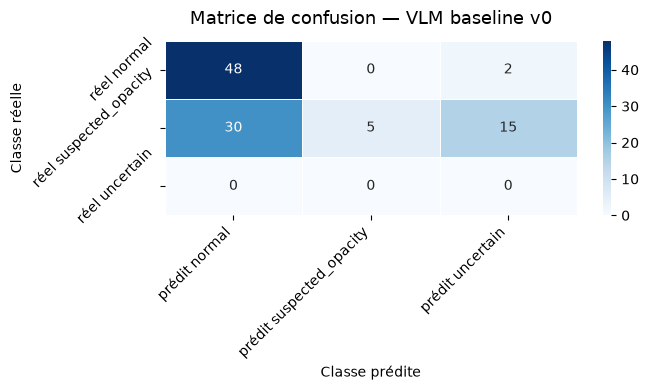


=== VLM improved v1 ===
Total : 100
Taux uncertain : 1.0%
Accuracy : 50.0%
Macro F1 : 0.336
Sensibilité : 0.0%
Spécificité : 100.0%


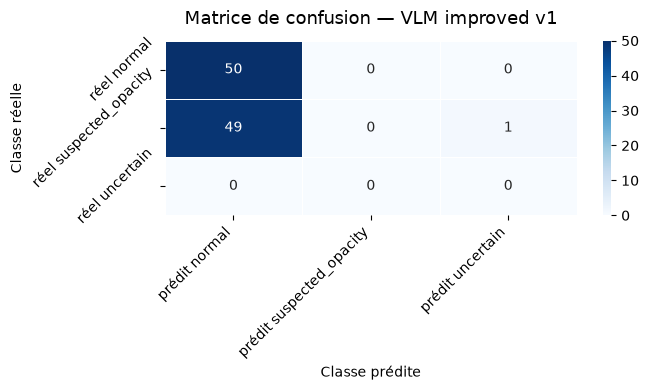


=== VLM improved v2 ===
Total : 24
Taux uncertain : 0.0%
Accuracy : 50.0%
Macro F1 : 0.333
Sensibilité : 0.0%
Spécificité : 100.0%


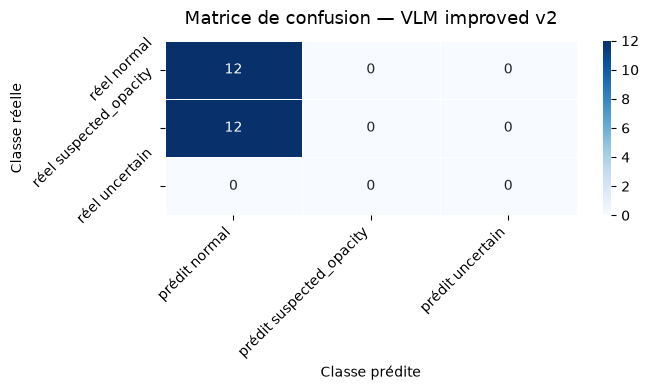


=== VLM improved v3 ===
Total : 26
Taux uncertain : 0.0%
Accuracy : 65.4%
Macro F1 : 0.653
Sensibilité : 57.1%
Spécificité : 75.0%


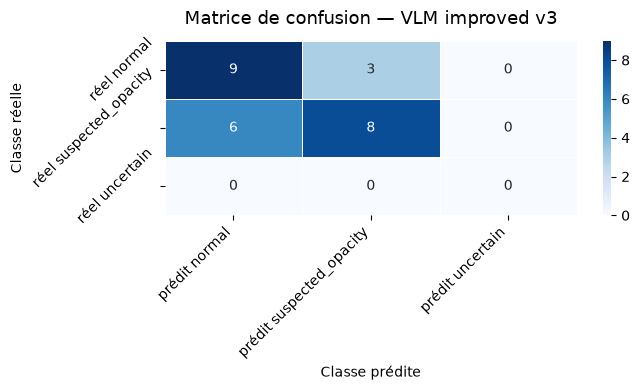


=== VLM improved v4 ===
Total : 115
Taux uncertain : 0.9%
Accuracy : 78.3%
Macro F1 : 0.786
Sensibilité : 78.3%
Spécificité : 78.2%


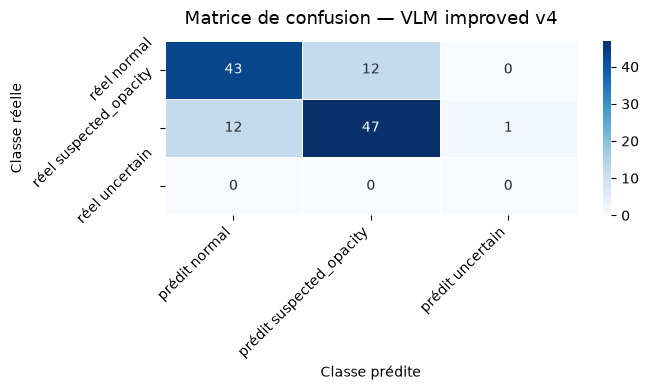


=== VLM improved v5 ===
Total : 100
Taux uncertain : 14.0%
Accuracy : 65.0%
Macro F1 : 0.699
Sensibilité : 62.0%
Spécificité : 68.0%


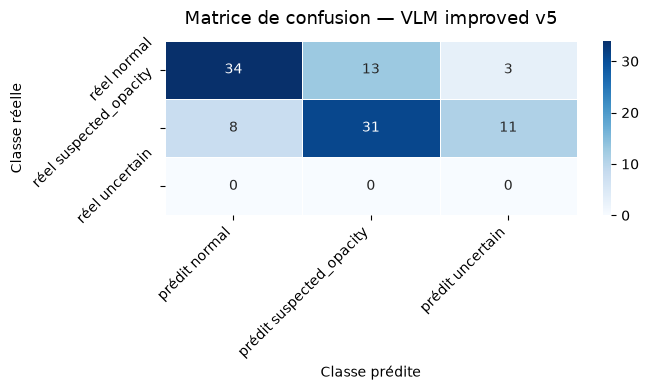

In [14]:
from src.metrics import sensitivity, specificity, confusion_matrix_numpy, macro_f1

CLASSES = ['normal', 'suspected_opacity', 'uncertain']

def compute_metrics_df(df, gt_col='ground_truth_label', pred_col='predicted_class'):
    valid = df.dropna(subset=[gt_col, pred_col])
    n = len(valid)
    accuracy = (valid[gt_col] == valid[pred_col]).mean()
    uncertain_rate = (valid[pred_col] == 'uncertain').mean()

    return {
        'n': n,
        'accuracy': accuracy,
        'macro_f1': macro_f1(valid[gt_col], valid[pred_col]),
        'sensitivity': sensitivity(valid[gt_col], valid[pred_col]),
        'specificity': specificity(valid[gt_col], valid[pred_col]),
        'uncertain_rate': uncertain_rate,
    }

# liste des prompts reellement presents dans la base, tries par id
# (plus robuste que deviner l'id a partir du numero de version)
prompt_keys = df[['prompt_id', 'prompt_name', 'prompt_version']].drop_duplicates().sort_values('prompt_id')

for _, row in prompt_keys.iterrows():
    df_version = df[df['prompt_id'] == row['prompt_id']]

    PROMPT_NAME = row['prompt_name']
    PROMPT_VERSION = row['prompt_version']

    m = compute_metrics_df(df_version)

    print(f'\n=== VLM {PROMPT_NAME} {PROMPT_VERSION} ===')
    print(f'Total : {m["n"]}')
    print(f'Taux uncertain : {m["uncertain_rate"]:.1%}')
    print(f'Accuracy : {m["accuracy"]:.1%}')
    print(f'Macro F1 : {m["macro_f1"]:.3f}')
    print(f'Sensibilité : {m["sensitivity"]:.1%}')
    print(f'Spécificité : {m["specificity"]:.1%}')

    # Matrice de confusion : combien de cas dans chaque case (reel x predit)
    cm = confusion_matrix_numpy(df_version['ground_truth_label'], df_version['predicted_class'], CLASSES)
    cm_df = pd.DataFrame(cm,
        index=[f'réel {c}' for c in CLASSES],
        columns=[f'prédit {c}' for c in CLASSES])

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
    ax.set_title(f'Matrice de confusion — VLM {PROMPT_NAME} {PROMPT_VERSION}', fontsize=13, pad=12)
    ax.set_ylabel('Classe réelle')
    ax.set_xlabel('Classe prédite')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Amélioration mesurée par rapport à la baseline

Nous visons une améliorationd de 20% par rapport à la baselune, il faut donc comparer les résultats du meilleur prompt avec ceux de la baseline (`baseline_prompt_0`) en utilisant les mêmes métriques.

Ici on prend automatiquement le prompt amélioré (`improved_prompt_4`) avec le meilleur macro-F1 et on le compare à la baseline, métrique par métrique.

In [17]:
# tableau recapitulatif : une ligne de metriques par prompt
summary_rows = []
for _, row in prompt_keys.iterrows():
    df_version = df[df['prompt_id'] == row['prompt_id']]
    m = compute_metrics_df(df_version)
    m['prompt_name'] = row['prompt_name']
    m['prompt_version'] = row['prompt_version']
    summary_rows.append(m)

summary_df = pd.DataFrame(summary_rows).set_index(['prompt_name', 'prompt_version'])
summary_df

n  accuracy  macro_f1  sensitivity  specificity  \
prompt_name prompt_version                                                      
baseline    v0              100  0.530000  0.465909     0.100000     0.960000   
improved    v1              100  0.500000  0.335570     0.000000     1.000000   
            v2               24  0.500000  0.333333     0.000000     1.000000   
            v3               26  0.653846  0.653333     0.571429     0.750000   
            v4              115  0.782609  0.785867     0.783333     0.781818   
            v5              100  0.650000  0.699352     0.620000     0.680000   

                            uncertain_rate  
prompt_name prompt_version                  
baseline    v0                    0.170000  
improved    v1                    0.010000  
            v2                    0.000000  
            v3                    0.000000  
            v4                    0.008696  
            v5                    0.140000

In [18]:
# on compare la baseline au meilleur prompt ameliore (le plus haut macro F1)
baseline_row = summary_df.loc['baseline'].iloc[0]
improved_rows = summary_df.loc['improved']
best_version = improved_rows['macro_f1'].idxmax()
best_row = improved_rows.loc[best_version]

print(f"Baseline (v0) vs meilleur prompt ameliore ({best_version})\n")
for metric in ['accuracy', 'macro_f1', 'sensitivity', 'specificity', 'uncertain_rate']:
    gain = best_row[metric] - baseline_row[metric]
    print(f"{metric:12s} : baseline {baseline_row[metric]:.1%}  ->  {best_version} {best_row[metric]:.1%}  (gain {gain:+.1%})")

Baseline (v0) vs meilleur prompt ameliore (v4)

accuracy     : baseline 53.0%  ->  v4 78.3%  (gain +25.3%)
macro_f1     : baseline 46.6%  ->  v4 78.6%  (gain +32.0%)
sensitivity  : baseline 10.0%  ->  v4 78.3%  (gain +68.3%)
specificity  : baseline 96.0%  ->  v4 78.2%  (gain -17.8%)
uncertain_rate : baseline 17.0%  ->  v4 0.9%  (gain -16.1%)


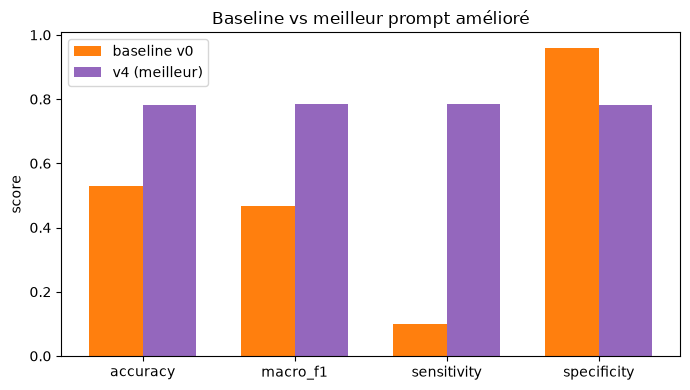

In [19]:
# graphique : baseline vs meilleur prompt ameliore, sur les 4 metriques principales
metrics_to_plot = ['accuracy', 'macro_f1', 'sensitivity', 'specificity']
x = range(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([i - width / 2 for i in x], [baseline_row[m] for m in metrics_to_plot], width, label='baseline v0', color='tab:orange')
ax.bar([i + width / 2 for i in x], [best_row[m] for m in metrics_to_plot], width, label=f'{best_version} (meilleur)', color='tab:purple')

ax.set_xticks(list(x))
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel('score')
ax.set_title('Baseline vs meilleur prompt amélioré')
ax.legend()
plt.tight_layout()
plt.show()

On note donc une nette amélioration avec le prompt v4 `improved_prompt_4.txt`. Toutefois, il ne s'agit ici que de la phase de recherche donc ce prompt est à tester sur le dataset rsna.

## 4. Analyse des erreurs

On cherche ici s'il existe un **biais systématique** derrière les erreurs (luminosité, taille d'image...) plutôt que des erreurs purement aléatoires

### Biais de luminosité ?

C:\Users\auber.MSI\AppData\Local\Temp\ipykernel_5340\1781179079.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


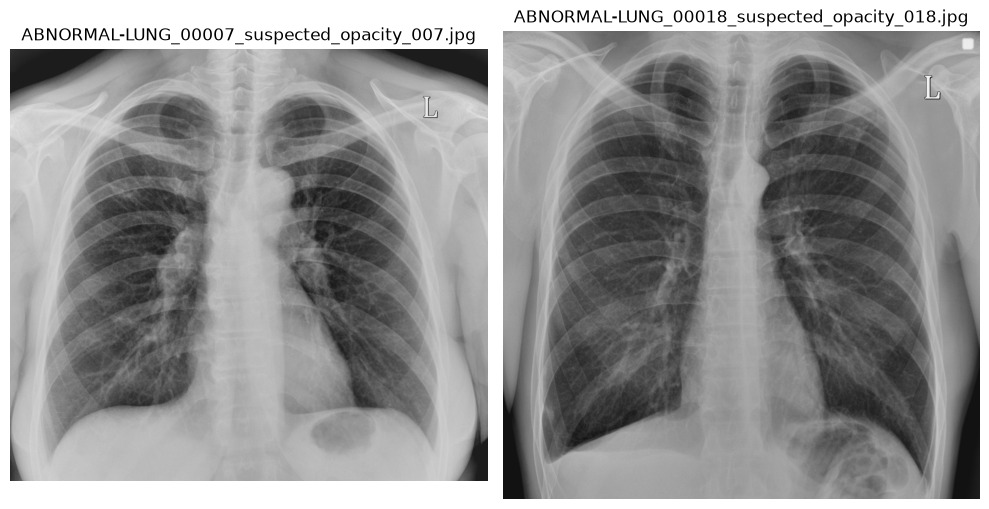

In [20]:
import os
import numpy as np
from PIL import Image
import pandas as pd

images = [
    "ABNORMAL-LUNG_00007_suspected_opacity_007.jpg",
    "ABNORMAL-LUNG_00018_suspected_opacity_018.jpg",
]

PATH_IMG = Path('..') / 'data' / 'brutes_kaggle'

fig, axes = plt.subplots(1, len(images), figsize=(5 * len(images), 5))

for ax, filename in zip(axes, images):
    img = Image.open(PATH_IMG / filename)
    ax.imshow(img, cmap="gray")
    ax.set_title(filename)
    ax.axis("off")

plt.legend()
plt.tight_layout()
plt.show()

L'image ID 7 est très clair par rapport au autres. Pareil pour celles mal classifé en normal

In [18]:
print(df.columns.tolist())
print(df.head(2))

['case_id', 'run_id', 'evaluation_id', 'prompt_id', 'prompt_name', 'prompt_version', 'ground_truth_label', 'predicted_class', 'confidence', 'latency']
   case_id  run_id  evaluation_id  prompt_id prompt_name prompt_version  \
0       17       1              1          1    baseline             v0   
1       29      83             83          1    baseline             v0   

  ground_truth_label predicted_class  confidence  latency  
0  suspected_opacity          normal        0.95    52971  
1  suspected_opacity          normal        0.95    35864  


In [19]:
import os
import numpy as np
from PIL import Image
import pandas as pd

BASE = Path('..') / 'data' / 'brutes_kaggle'

# Mapping case_id -> fichier
id_to_file = {}
for f in os.listdir(BASE):
    parts = f.split('_')
    case_id = int(parts[1])  # ex: "00417" -> 417
    id_to_file[case_id] = f

def analyze_brightness(image_path):
    try:
        img = Image.open(image_path).convert("L")
        arr = np.array(img)
        return {
            "mean_brightness": arr.mean(),
            "std_brightness": arr.std(),
            "p10": np.percentile(arr, 10),
            "p90": np.percentile(arr, 90),
        }
    except:
        return {"mean_brightness": None, "std_brightness": None, "p10": None, "p90": None}

results = []
for _, row in df.iterrows():
    filename = id_to_file.get(row["case_id"])
    if filename is None:
        continue
    stats = analyze_brightness(BASE / filename)
    stats["case_id"] = row["case_id"]
    stats["ground_truth_label"] = row["ground_truth_label"]
    stats["predicted_class"] = row["predicted_class"]
    stats["correct"] = row["ground_truth_label"] == row["predicted_class"]
    results.append(stats)

df_bright = pd.DataFrame(results)
df_bright

,mean_brightness,std_brightness,p10,p90,case_id,ground_truth_label,predicted_class,correct
0,132.297522,35.857077,81.0,165.0,17,suspected_opacity,normal,False
1,126.198231,40.701361,68.0,172.0,29,suspected_opacity,normal,False
2,116.680164,39.846513,68.0,157.0,34,suspected_opacity,normal,False
3,132.806435,37.925475,73.0,173.0,37,suspected_opacity,normal,False
4,123.233150,38.367391,67.0,167.0,72,suspected_opacity,normal,False
...,...,...,...,...,...,...,...,...
460,124.647971,38.719853,70.0,167.0,849,normal,normal,True
461,99.468033,41.434814,40.0,146.0,852,normal,normal,True
462,116.235421,33.924158,68.0,154.0,879,normal,suspected_opacity,False
463,125.382971,43.744394,60.0,172.0,884,normal,normal,True


In [20]:
df_bright.groupby(["ground_truth_label", "correct"])["mean_brightness"].describe()

count        mean        std        min  \
ground_truth_label correct                                            
normal             False     33.0  118.468134  13.740209  96.203660   
                   True     196.0  120.361018  12.491332  96.203660   
suspected_opacity  False    145.0  130.740775  13.659256  98.706196   
                   True      91.0  131.125977  15.584225  98.706196   

                                   25%         50%         75%         max  
ground_truth_label correct                                                  
normal             False    108.873940  117.594505  132.139284  143.554102  
                   True     111.819292  119.501246  128.072360  151.985897  
suspected_opacity  False    123.233150  129.709274  138.703300  168.090696  
                   True     121.479736  128.688326  138.703300  168.090696

Malgrés les observation à l'oeil nu, les valeurs obtenues sur tout le dataset testé, la luminosité est en moyenne la même pour les images bien et mal classifiés

### La taille de l'image a-t-elle un impacte sur la calssification ?

Tout comme la luminosité, la taille des images semble plus petite (les poumons sont plus isolés de l'ensemble) pour les images mal classifies que les images bien classifiés.

In [21]:
import os
from pathlib import Path
import numpy as np
from PIL import Image
import pandas as pd

BASE = Path('..') / 'data' / 'brutes_kaggle'

# Mapping case_id -> fichier
id_to_file = {}
for f in os.listdir(BASE):
    parts = f.split('_')
    case_id = int(parts[1])
    id_to_file[case_id] = f

def analyze_size(image_path):
    img = Image.open(image_path)
    return {
        "width": img.size[0],
        "height": img.size[1],
        "mode": img.mode,
    }

# Appliqué sur tous les cas
results = []
for case_id in df['case_id']:
    if case_id not in id_to_file:
        print(f"case_id {case_id} : fichier introuvable")
        continue
    try:
        info = analyze_size(BASE / id_to_file[case_id])
        info["case_id"] = case_id
        results.append(info)
    except Exception as e:
        print(f"case_id {case_id} : erreur {e}")

sizes_df = pd.DataFrame(results)
print(sizes_df.describe())  # stats globales (min/max/moyenne width, height)
sizes_df

             width       height     case_id
count   465.000000   465.000000  465.000000
mean   2352.273118  2217.767742  416.739785
std     239.521138   304.544632  250.031134
min    1615.000000  1547.000000    1.000000
25%    2212.000000  2013.000000  195.000000
50%    2372.000000  2215.000000  413.000000
75%    2516.000000  2417.000000  623.000000
max    2892.000000  2953.000000  890.000000


,width,height,mode,case_id
0,2411,2388,RGB,17
1,2314,2202,RGB,29
2,1615,1547,RGB,34
3,2051,1999,RGB,37
4,2247,2083,RGB,72
...,...,...,...,...
460,2498,2562,RGB,849
461,2314,2295,RGB,852
462,2353,2044,RGB,879
463,2198,2077,RGB,884


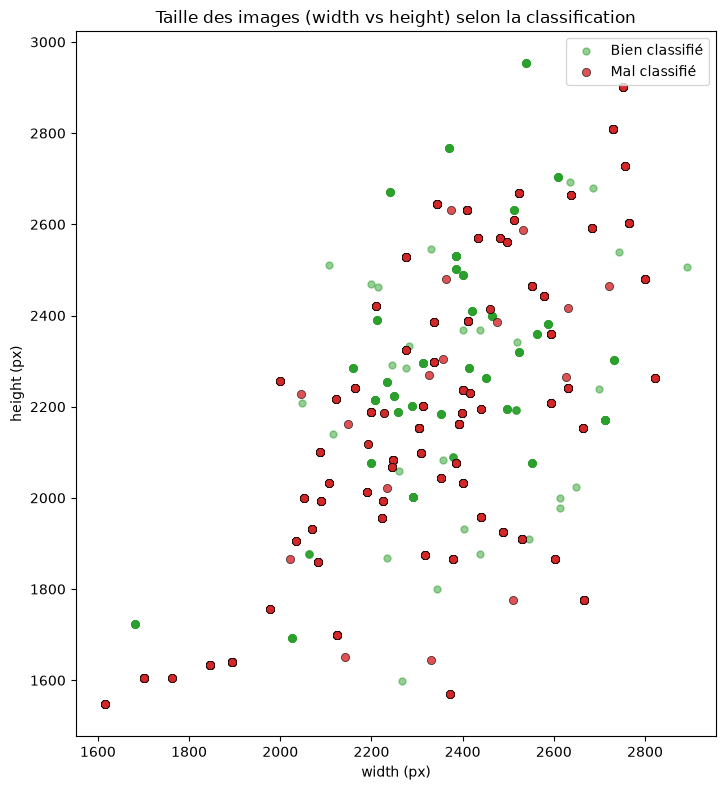

In [22]:

# Récupère les évaluations (base Kaggle explicitement, pas la base par defaut)
evals_df = pd.DataFrame(get_evaluations(DB_PATH))

if "correct" not in evals_df.columns:
    evals_df["correct"] = (evals_df["predicted_class"] == evals_df["ground_truth_label"]).astype(int)

# Si un case_id a été évalué avec plusieurs prompts, filtre sur un seul avant de merger
# evals_df = evals_df[evals_df["prompt_id"] == 3]  # décommente et ajuste si besoin

# Merge avec les tailles
merged = sizes_df.merge(evals_df[["case_id", "correct"]], on="case_id", how="inner")

correct = merged[merged["correct"] == 1]
wrong   = merged[merged["correct"] == 0]

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(correct["width"], correct["height"], c="tab:green", label="Bien classifié", alpha=0.5, s=25)
ax.scatter(wrong["width"],   wrong["height"],   c="tab:red",   label="Mal classifié",  alpha=0.8, s=35, edgecolors="black", linewidths=0.5)

ax.set_xlabel("width (px)")
ax.set_ylabel("height (px)")
ax.set_title("Taille des images (width vs height) selon la classification")
ax.legend()
ax.set_aspect("equal", adjustable="box")  # ratio 1:1 pour repérer les images carrées vs rectangulaires
plt.tight_layout()
plt.show()
correct = merged[merged["correct"] == 1]
wrong   = merged[merged["correct"] == 0]

ax.scatter(correct["case_id"], correct["width"], c="tab:green", label="Bien classifié", alpha=0.6, s=20)
ax.scatter(wrong["case_id"],   wrong["width"],   c="tab:red",   label="Mal classifié",  alpha=0.8, s=30)

ax.set_xlabel("case_id")
ax.set_ylabel("width (px)")
ax.set_title("Taille d'image (width) vs cas, coloré par classification")
ax.legend()
plt.show()

La répartition de la taille et des images bien classifés semble ne montrer aucun lien avec les mauvaises classifications. 

## 5. Problème de latence

### Métrique de latence dans la base

La colonne `runs.latency_ms` est en **millisecondes** et couvre :
- tokenisation de l'image + du prompt
- `model.generate(...)`
- le décodage de la réponse

On ne prend pas en compte la pause de refroidissement GPU (`_wait_for_gpu_cooldown`) qui a lieu juste après la mesure pour attendre que le gpu refroidisse

In [6]:
# moyenne de latence en millisecondes, tous prompts confondus (ordre de grandeur rapide, pas la metrique officielle)
latency = df['latency'].mean()
latency

np.float64(30174.449462365592)

Le protocole d'évaluation demande la **latence médiane, par prompt** (pas une moyenne globale tous prompts mélangés) : la médiane résiste mieux aux quelques cas très lents (GPU qui chauffe) qui font grimper une moyenne sans être représentatifs du cas typique.

In [7]:
# latence mediane par prompt, en secondes (la metrique demandee par le protocole d'evaluation)
median_by_prompt = df.groupby(['prompt_name', 'prompt_version'])['latency'].median() / 1000
median_by_prompt.rename('latence_mediane_s')

prompt_name  prompt_version
baseline     v0                39.5795
improved     v1                39.4975
             v2                39.4210
             v3                41.7625
             v4                21.5790
             v5                18.6725
Name: latence_mediane_s, dtype: float64

### Changements faits pour améliorer la latence

Trois changements dans `src/inference.py` :

* **`bnb_4bit_compute_dtype=torch.bfloat16`** dans le `BitsAndBytesConfig` (`_load_vlm`). Par défaut les calculs de la quantification 4-bit se faisaient en float32. Le bfloat16 est calculé plus vite sur les tensor cores de la RTX 4050 (pc de test), sans changer la mémoire utilisée.
* **`max_new_tokens` réduit de 300 à 200** (`vlm_predict_placeholder`). Le JSON de sortie n'a pas besoin de 300 tokens. Moins de tokens à générer permet de rédire la latence.
* **Correction du chrono** : `start = time.perf_counter()` a été déplacé après `_load_vlm()`. Avant, le tout premier appel d'un script ou du serveur web incluait le temps de chargement du modèle dans sa latence et donc gonflait artificiellement la mesure.

Ces trois changements ont été appliqués entre le **04/07 et le 05/07**. Pour mesurer leur effet, on compare **20 cas exécutés avant** l'optimisation à **20 cas du prompt `improved v4` exécutés après**. La latence dépend de la configuration de génération (nombre de tokens, dtype), **pas du texte du prompt** : la comparaison est donc valide même si les cas « avant » viennent de prompts variés (le prompt `v4` n'a que 2 runs avant l'optimisation, trop peu pour un échantillon). On regarde la **médiane**, plus robuste aux quelques cas lents (GPU qui chauffe).

Avant optim (20 cas, config initiale) : mediane 41.1 s
Apres optim (20 cas, prompt v4)        : mediane 18.4 s

Gain : mediane 41.1 s -> 18.4 s, soit 55% plus rapide (2.2x)


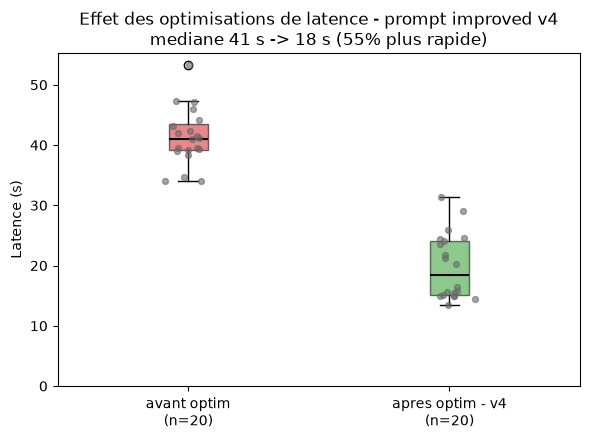

In [8]:
import sqlite3
import numpy as np

# L'optimisation de latence (max_new_tokens 300->200, bfloat16, chrono demarre apres chargement du modele)
# a ete appliquee entre le 02/07 et le 04/07. La latence depend de la CONFIG DE GENERATION, pas du texte
# du prompt -> on compare 20 runs AVANT optim (tous prompts, config initiale ~40s) a 20 runs APRES optim
# sur le prompt v4 (~20s). NB : v4 n'a que 2 runs avant l'optim, d'ou l'echantillon "tous prompts" cote avant.
CUTOFF = '2026-07-03'   # frontiere de l'optimisation (entre le lot du 02/07 et celui du 04/07)
N = 20
SEED = 42

conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row
prompt_v4_id = conn.execute(
    "SELECT id FROM prompts WHERE prompt_name = 'improved' AND prompt_version = 'v4'"
).fetchone()['id']

before = pd.DataFrame([dict(r) for r in conn.execute(
    "SELECT latency_ms, created_at FROM runs WHERE latency_ms > 0 AND created_at < ?",
    (CUTOFF,)
).fetchall()])
after = pd.DataFrame([dict(r) for r in conn.execute(
    "SELECT latency_ms, created_at FROM runs WHERE latency_ms > 0 AND created_at >= ? AND prompt_id = ?",
    (CUTOFF, prompt_v4_id)
).fetchall()])
conn.close()

# echantillon reproductible de 20 cas de chaque cote
before_s = before.sample(N, random_state=SEED)['latency_ms'] / 1000
after_s  = after.sample(N, random_state=SEED)['latency_ms'] / 1000

med_before, med_after = before_s.median(), after_s.median()
gain_pct = (1 - med_after / med_before) * 100
print(f"Avant optim ({N} cas, config initiale) : mediane {med_before:.1f} s")
print(f"Apres optim ({N} cas, prompt v4)        : mediane {med_after:.1f} s")
print(f"\nGain : mediane {med_before:.1f} s -> {med_after:.1f} s, soit {gain_pct:.0f}% plus rapide ({med_before/med_after:.1f}x)")

# boxplot : montre la mediane ET la dispersion des 20 cas (plus honnete que 2 barres isolees)
fig, ax = plt.subplots(figsize=(6, 4.5))
bp = ax.boxplot([before_s, after_s],
                tick_labels=[f"avant optim\n(n={N})", f"apres optim - v4\n(n={N})"],
                patch_artist=True, medianprops=dict(color='black', linewidth=1.5))
for patch, color in zip(bp['boxes'], ['tab:red', 'tab:green']):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)

# points individuels legerement decales pour voir chaque cas
rng = np.random.default_rng(SEED)
for i, data in enumerate([before_s, after_s], start=1):
    ax.scatter(rng.normal(i, 0.045, len(data)), data, s=18, color='dimgray', alpha=0.6, zorder=3)

ax.set_ylabel("Latence (s)")
ax.set_ylim(bottom=0)
ax.set_title(f"Effet des optimisations de latence - prompt improved v4\nmediane {med_before:.0f} s -> {med_after:.0f} s ({gain_pct:.0f}% plus rapide)")
plt.tight_layout()
plt.show()

## 6. Dataset RSNA : historique des prompts et tentative de vote

Une fois passé sur le dataset RSNA (dataset officiel du cahier des charges, voir `notebooks/05_...` et `notebooks/06_prompt_comparison.ipynb`), le prompt `improved v4` qui marchait bien sur Kaggle (78% accuracy) est tombé à 40%. Les images RSNA sont des radios cliniques réelles (portable/AP, câbles, tubes, tissu mammaire), pas un dataset curé.

### Prompts testés sur RSNA

| Prompt | Idée | Accuracy | Sensibilité | Spécificité |
|---|---|---|---|---|
| v4 | Prompt simple  | 40% | 64% | 16% |
| v5 | Raisonnement réordonné + checklist (repris de Kaggle) | 40% | 70% | 10% |
| v6 | Checklist artefacts (câbles, tubes, tissu mammaire) | 35% | 40% | 30% |
| v7 | v4 + 1 ligne "exclure le matériel externe" | 35% | 70% | 0% |
| v8 | v4 + 1 ligne "ne regarder que les poumons" | 35% | — | — |
| v9 | Seuil conservateur ("normal par défaut sauf preuve claire") | 30% | 0% | 75% |
| **v10** | **Comparaison de symétrie gauche/droite uniquement** | **71.7%** | **51.7%** | **91.7%** |
| v11 | Prompt minimal, sans framing accumulé | 60% | 100% | 0% |

v10 est le seul prompt qui casse le plafond ~35-40%. En changeant la logique de décision (comparaison relative) plutôt qu'en empilant des règles d'exclusion sur le même squelette que v4.

### Tentative de vote de prompts

Inspiré d'une étude réelle sur MedGemma-4B-it pour la détection de pneumonie pédiatrique ([medRxiv, avril 2026](https://www.medrxiv.org/content/10.64898/2026.04.10.26347909v1.full)), qui fait voter 15 prompts différents (majorité / vote pondéré) plutôt que d'utiliser un seul prompt élaboré.

- **Vote 1 (v5+v6+v7+v8)** : accuracy 25%, pire que n'importe lequel des 4 prompts pris seul. Ces 4 prompts partagent le même squelette (variantes de v4) et le même biais (ils ne disent presque jamais "normal"). Leurs erreurs sont corrélées, pas indépendantes, donc le vote ne fait qu'amplifier le biais commun.
- **Vote 2 (v9+v10+v11)** : prompts délibérément conçus avec des biais opposés (normal par défaut / équilibré / opacité par défaut). Accuracy 50%, plus équilibré que v9 ou v11 seuls, mais toujours moins bon que v10 seul (60% sur le même échantillon).

**Conclusion retenue** : le vote de prompts n'a battu le meilleur prompt individuel dans aucun des deux essais. Un ensemble n'aide que si les erreurs de ses membres sont réellement indépendantes.